# 02 — Preprocessing & Detrending
Takes raw `.fits` light curves from `data/raw/` and produces clean, normalized light curves saved to `data/processed/`.

## 1. Imports

In [1]:
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import glob
import warnings
warnings.filterwarnings('ignore')

print('Imports OK!')

Imports OK!


c:\Users\Alivia Hossain\Desktop\exoplanet_detection\Exoplanet_detection\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 2. Configuration

In [2]:
RAW_DIR       = '../data/raw/'
PROCESSED_DIR = '../data/processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Detrending parameters
WINDOW_LENGTH = 401    # Savitzky-Golay window (must be odd). Larger = smoother
SIGMA_CLIP    = 4      # Remove points > 4 sigma from median

raw_files = glob.glob(os.path.join(RAW_DIR, 'TIC_*.fits'))
print(f'Found {len(raw_files)} raw light curve files')

Found 20 raw light curve files


## 3. Preprocessing Function
For each light curve we:
1. Remove NaN values
2. Remove outliers (sigma clipping)
3. Flatten/detrend using Savitzky-Golay filter
4. Normalize to flux = 1.0

In [3]:
def preprocess_lightcurve(fits_path, window_length=401, sigma=4):
    """
    Load and preprocess a TESS light curve.
    Returns a cleaned LightCurve object or None if it fails.
    """
    try:
        # Load
        lc = lk.read(fits_path)

        # Use SAP or PDCSAP flux (PDCSAP is pre-corrected by NASA pipeline)
        if hasattr(lc, 'pdcsap_flux'):
            lc = lc.select_flux('pdcsap_flux')

        # Step 1: Remove NaN
        lc = lc.remove_nans()

        # Step 2: Remove outliers (cosmic rays, momentum dumps)
        lc = lc.remove_outliers(sigma=sigma)

        # Step 3: Flatten (detrend) — removes stellar variability trends
        # window_length must be odd and smaller than data length
        wl = min(window_length, len(lc) // 2 * 2 - 1)
        lc_flat = lc.flatten(window_length=wl)

        # Step 4: Normalize to median = 1
        lc_norm = lc_flat.normalize()

        return lc_norm

    except Exception as e:
        return None

print('Preprocessing function defined!')

Preprocessing function defined!


## 4. Process All Light Curves & Save as CSV

In [4]:
success_count = 0
fail_count    = 0
summary       = []

for fits_path in tqdm(raw_files, desc='Preprocessing'):
    tic_id = os.path.basename(fits_path).replace('TIC_', '').replace('.fits', '')
    csv_path = os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv')

    # Skip if already processed
    if os.path.exists(csv_path):
        success_count += 1
        continue

    lc_clean = preprocess_lightcurve(fits_path, WINDOW_LENGTH, SIGMA_CLIP)

    if lc_clean is None:
        fail_count += 1
        continue

    # Save time and flux as simple CSV
    df = pd.DataFrame({
        'time': lc_clean.time.value,
        'flux': lc_clean.flux.value,
        'flux_err': lc_clean.flux_err.value if lc_clean.flux_err is not None else np.nan
    })
    df.to_csv(csv_path, index=False)
    success_count += 1
    summary.append({'tic_id': tic_id, 'n_points': len(df)})

print(f'\n✅ Processed successfully : {success_count}')
print(f'❌ Failed                 : {fail_count}')

Preprocessing: 100%|██████████| 20/20 [00:02<00:00,  7.06it/s]


✅ Processed successfully : 20
❌ Failed                 : 0


## 5. Before vs After — Visual Comparison

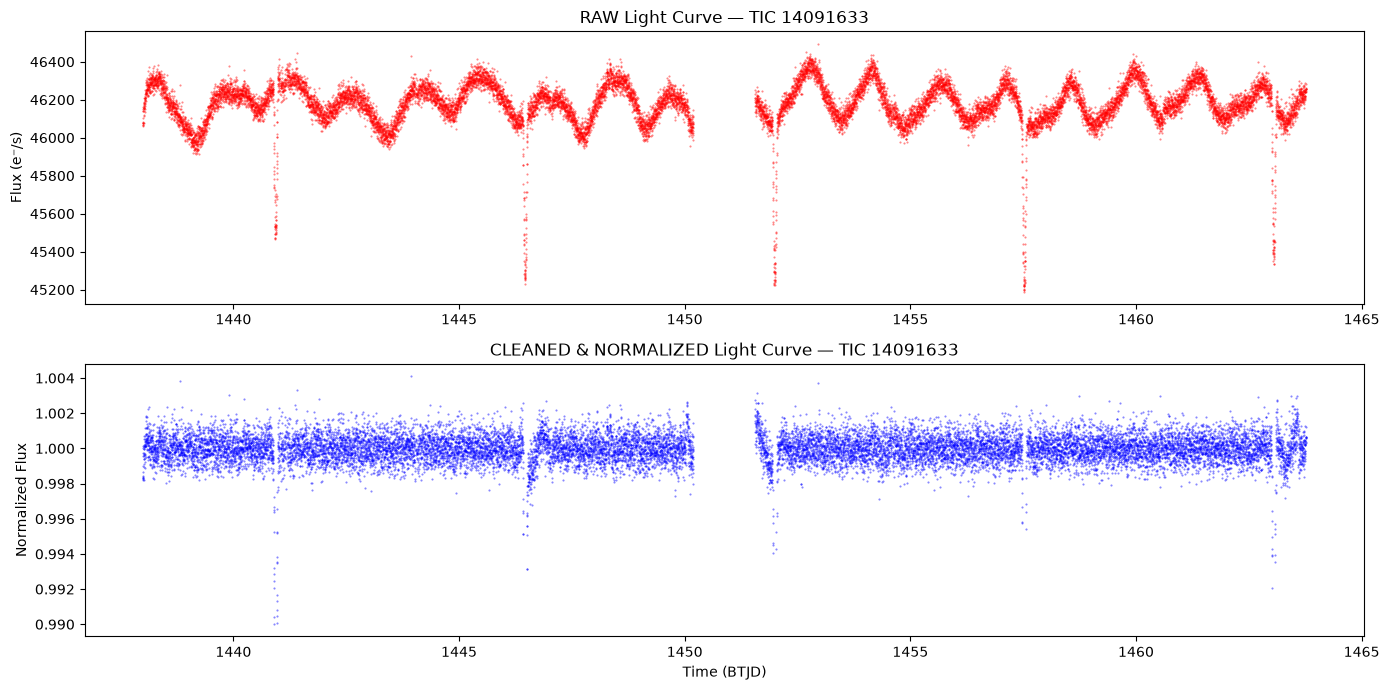

Comparison plot saved!


In [5]:
# Pick first file for visualization
sample_fits = raw_files[0]
tic_id      = os.path.basename(sample_fits).replace('TIC_','').replace('.fits','')

lc_raw   = lk.read(sample_fits)
lc_clean = preprocess_lightcurve(sample_fits)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Raw
axes[0].plot(lc_raw.time.value, lc_raw.flux.value,
             'r.', markersize=1, alpha=0.5)
axes[0].set_title(f'RAW Light Curve — TIC {tic_id}')
axes[0].set_ylabel('Flux (e⁻/s)')

# Cleaned
axes[1].plot(lc_clean.time.value, lc_clean.flux.value,
             'b.', markersize=1, alpha=0.5)
axes[1].set_title(f'CLEANED & NORMALIZED Light Curve — TIC {tic_id}')
axes[1].set_ylabel('Normalized Flux')
axes[1].set_xlabel('Time (BTJD)')

plt.tight_layout()
plt.savefig('../outputs/plots/before_after_preprocessing.png', dpi=150)
plt.show()
print('Comparison plot saved!')

## 6. Also Preprocess Labeled Data

In [6]:
LABELED_DIR           = '../data/labeled/'
LABELED_PROCESSED_DIR = '../data/labeled/processed/'
os.makedirs(LABELED_PROCESSED_DIR, exist_ok=True)

labeled_fits = glob.glob(os.path.join(LABELED_DIR, '*.fits'))
print(f'Found {len(labeled_fits)} labeled FITS files')

for fits_path in tqdm(labeled_fits, desc='Processing labeled data'):
    fname    = os.path.basename(fits_path).replace('.fits', '')
    csv_path = os.path.join(LABELED_PROCESSED_DIR, f'{fname}.csv')

    lc_clean = preprocess_lightcurve(fits_path)
    if lc_clean is None:
        continue

    df = pd.DataFrame({
        'time'     : lc_clean.time.value,
        'flux'     : lc_clean.flux.value,
        'flux_err' : lc_clean.flux_err.value
    })
    df.to_csv(csv_path, index=False)

print('Labeled data preprocessing done!')

Found 104 labeled FITS files


Processing labeled data: 100%|██████████| 104/104 [00:18<00:00,  5.64it/s]

Labeled data preprocessing done!


---
## ✅ Done!
**What was saved:**
- `data/processed/TIC_*.csv` — cleaned light curves (time, flux, flux_err)
- `data/labeled/processed/*.csv` — cleaned labeled light curves
- `outputs/plots/before_after_preprocessing.png` — comparison plot

**Next Step → Run `03_bls_search.ipynb`**